# CRMLS Real Estate — Dataset Structuring, Validation & EDA
**IDX Exchange MLS Analytics Program**

Datasets:
- `CRMLSSold_Combined.csv` — Closed/sold transactions
- `CRMLSListing_Combined.csv` — Active/listed properties

Notebook Flow:

**Week 1**
1. Setup & Raw Data Loading

**Weeks 2–3**
2. Dataset Understanding
3. Missing Value Analysis
4. Numeric Distribution Review
5. Exploratory Questions & Findings

**Weeks 4–5 — Data Cleaning & Preparation**
6. Date Field Conversion
7. Column Selection & Type Enforcement
8. Invalid Numeric Value Flags & Removal
9. Missing Value Handling
10. Date Consistency Checks & Flags
11. Geographic Data Quality Checks
12. Before/After Summary & Data Type Confirmation
13. Save Analysis-Ready Datasets

## 1. Setup & Raw Data Loading

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize']  = 14
plt.rcParams['axes.labelsize']  = 12

print('Libraries loaded ✓')

Libraries loaded ✓


In [128]:
sold_raw    = pd.read_csv('CRMLSSold_Combined.csv',    low_memory=False)
listing_raw = pd.read_csv('CRMLSListing_Combined.csv', low_memory=False)

print(f'Sold raw shape:    {sold_raw.shape}')
print(f'Listing raw shape: {listing_raw.shape}')

Sold raw shape:    (606568, 81)
Listing raw shape: (675678, 71)


## 2. Dataset Understanding
Identify rows/columns, data types, and separate market analysis fields from metadata fields.

In [129]:
for label, df in [('SOLD', sold_raw), ('LISTING', listing_raw)]:
    print(f'=== {label} ===')
    print(f'  Rows:    {df.shape[0]:,}')
    print(f'  Columns: {df.shape[1]}')
    print(f'  Duplicates: {df.duplicated().sum():,}')
    print()

=== SOLD ===
  Rows:    606,568
  Columns: 81
  Duplicates: 0

=== LISTING ===
  Rows:    675,678
  Columns: 71
  Duplicates: 1



In [130]:
# Full dtype listing for sold
print('=== SOLD — Column dtypes ===')
print(sold_raw.dtypes.to_string())

=== SOLD — Column dtypes ===
BuyerAgentAOR                    object
ListAgentAOR                     object
Flooring                         object
ViewYN                           object
WaterfrontYN                     object
BasementYN                       object
PoolPrivateYN                    object
OriginalListPrice               float64
ListingKey                        int64
ListAgentEmail                   object
CloseDate                        object
ClosePrice                      float64
ListAgentFirstName               object
ListAgentLastName                object
Latitude                        float64
Longitude                       float64
UnparsedAddress                  object
PropertyType                     object
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                   object
BuyerOfficeName                  object
CoListOfficeName                 object
ListAgentFu

In [131]:
# Full dtype listing for listing
print('=== LISTING — Column dtypes ===')
print(listing_raw.dtypes.to_string())

=== LISTING — Column dtypes ===
OriginalListPrice               float64
ListingKey                        int64
CloseDate                        object
ClosePrice                      float64
ListAgentFirstName               object
ListAgentLastName                object
Latitude                        float64
Longitude                       float64
UnparsedAddress                  object
PropertyType                     object
LivingArea                      float64
ListPrice                       float64
DaysOnMarket                      int64
ListOfficeName                   object
BuyerOfficeName                  object
CoListOfficeName                 object
ListAgentFullName                object
CoListAgentFirstName             object
CoListAgentLastName              object
BuyerAgentMlsId                  object
BuyerAgentFirstName              object
BuyerAgentLastName               object
FireplacesTotal                 float64
AssociationFeeFrequency          object
AboveGra

In [132]:
sold_raw.head(3)

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,source_file
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,NaN,NaN,False,5000000.0,1095075487,erin@martinhomesteam.com,...,False,3.0,NaN,94595,NaN,30240.0,NaN,CRMLS,CRMLS_CCBE,CRMLSSold202401.csv
1,NaN,Mlslistings,NaN,False,NaN,NaN,NaN,NaN,1079166779,davidmartz@compass.com,...,False,2.0,Palm Springs Unified,92262,NaN,13504.0,NaN,CRMLS,CRMLS_MLSL,CRMLSSold202401.csv
2,Glendale,Southland,NaN,False,NaN,NaN,False,1890500.0,1075037759,karen.klein@theagencyre.com,...,False,2.0,Los Angeles Unified,91356,0.0,17873.0,NaN,CRMLS,CRMLS_CRM,CRMLSSold202401.csv


In [133]:
listing_raw.head(3)

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,source_file
0,2750.0,1156083912,NaN,NaN,Monica,Macias,33.565948,-117.226057,24120 Dolcetto Avenue 805,ResidentialLease,...,2500.0,0.0,False,2.0,Murrieta,92562,NaN,2500.0,NaN,CRMLSListing202401.csv
1,3795.0,1153559659,2026-04-01,3599.0,Monica,Macias,33.902828,-117.323435,8182 Bon View Drive,ResidentialLease,...,8712.0,1.0,False,2.0,Riverside Unified,92508,0.0,8712.0,NaN,CRMLSListing202401.csv
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,3920.0,3.0,False,1.0,Upper Lake Union,95464,0.0,3920.0,NaN,CRMLSListing202401.csv


In [134]:
# ── Market analysis fields vs metadata fields ──
market_fields_sold = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeSquareFeet',
    'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'PropertyType',
    'PropertySubType', 'City', 'PostalCode', 'CountyOrParish', 'CloseDate'
]

metadata_fields_sold = [
    c for c in sold_raw.columns if c not in market_fields_sold
]

print('SOLD — Market Analysis Fields:')
print([c for c in market_fields_sold if c in sold_raw.columns])
print(f'\nSOLD — Metadata / Agent / ID Fields ({len(metadata_fields_sold)} cols):')
print(metadata_fields_sold[:30], '...' if len(metadata_fields_sold) > 30 else '')

SOLD — Market Analysis Fields:
['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'PropertyType', 'PropertySubType', 'City', 'PostalCode', 'CountyOrParish', 'CloseDate']

SOLD — Metadata / Agent / ID Fields (67 cols):
['BuyerAgentAOR', 'ListAgentAOR', 'Flooring', 'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN', 'ListingKey', 'ListAgentEmail', 'ListAgentFirstName', 'ListAgentLastName', 'Latitude', 'Longitude', 'UnparsedAddress', 'ListOfficeName', 'BuyerOfficeName', 'CoListOfficeName', 'ListAgentFullName', 'CoListAgentFirstName', 'CoListAgentLastName', 'BuyerAgentMlsId', 'BuyerAgentFirstName', 'BuyerAgentLastName', 'FireplacesTotal', 'AssociationFeeFrequency', 'AboveGradeFinishedArea', 'ListingKeyNumeric', 'MLSAreaMajor', 'TaxAnnualAmount', 'MlsStatus'] ...


## 3. Missing Value Analysis
Calculate missing counts and percentages per column. Flag columns with >90% missing values and decide which to drop vs retain.

In [135]:
def missing_report(df, label):
    total = len(df)
    report = pd.DataFrame({
        'Missing Count':  df.isnull().sum(),
        'Missing %':      (df.isnull().sum() / total * 100).round(2),
        'Flag >90% null': df.isnull().mean() > 0.90
    }).sort_values('Missing %', ascending=False)
    report = report[report['Missing Count'] > 0]
    print(f'\n=== {label} — Missing Value Report ===')
    print(f'Total rows: {total:,} | Columns with any missing: {len(report)}')
    print()
    print(report.to_string())
    flagged = report[report['Flag >90% null']]
    if len(flagged):
        print(f'\n*** {len(flagged)} columns flagged for >90% null — consider dropping: {list(flagged.index)}')
    else:
        print('\nNo columns exceed 90% null threshold.')
    return report

sold_missing    = missing_report(sold_raw,    'SOLD')
listing_missing = missing_report(listing_raw, 'LISTING')


=== SOLD — Missing Value Report ===
Total rows: 606,568 | Columns with any missing: 69

                              Missing Count  Missing %  Flag >90% null
ElementarySchoolDistrict             606568     100.00            True
MiddleOrJuniorSchoolDistrict         606568     100.00            True
AboveGradeFinishedArea               606568     100.00            True
FireplacesTotal                      606568     100.00            True
CoveredSpaces                        606568     100.00            True
TaxYear                              606188      99.94            True
WaterfrontYN                         606233      99.94            True
BusinessType                         604820      99.71            True
TaxAnnualAmount                      604100      99.59            True
BelowGradeFinishedArea               603907      99.56            True
BasementYN                           596623      98.36            True
BuilderName                          582486      96.03     

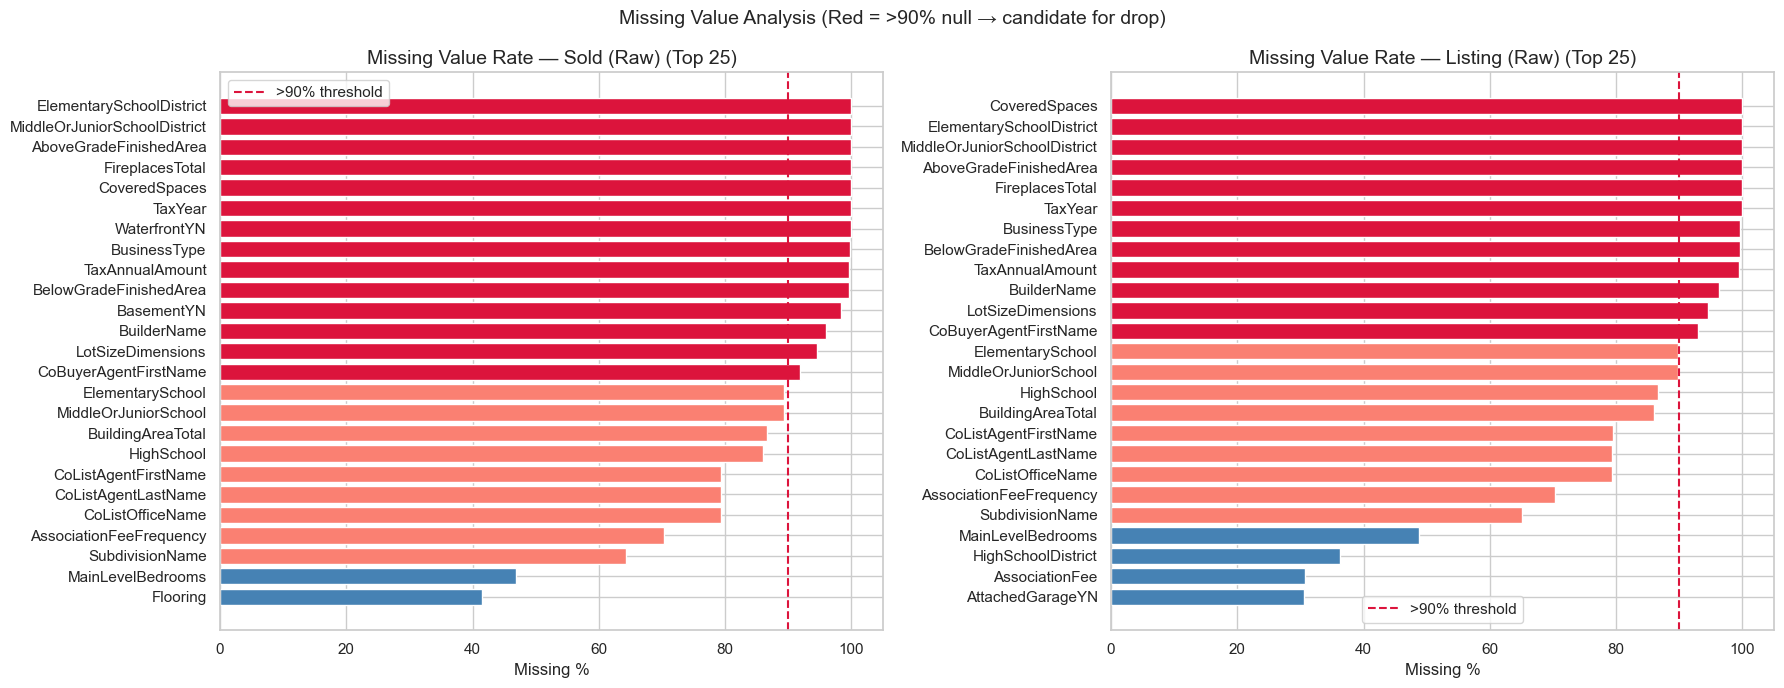

In [136]:
# Visual: top 25 columns by missing % for each dataset
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, report, label in zip(axes, [sold_missing, listing_missing], ['Sold (Raw)', 'Listing (Raw)']):
    top = report.head(25)
    colors = ['crimson' if x > 90 else 'salmon' if x > 50 else 'steelblue' for x in top['Missing %']]
    ax.barh(top.index[::-1], top['Missing %'][::-1], color=colors[::-1], edgecolor='white')
    ax.axvline(90, color='crimson', linestyle='--', linewidth=1.5, label='>90% threshold')
    ax.set_title(f'Missing Value Rate — {label} (Top 25)')
    ax.set_xlabel('Missing %')
    ax.legend()

plt.suptitle('Missing Value Analysis (Red = >90% null → candidate for drop)', fontsize=14)
plt.tight_layout()
plt.show()

## 4. Numeric Distribution Review
Histograms, boxplots, and percentile summaries for key numeric fields:
`ClosePrice`, `ListPrice`, `OriginalListPrice`, `LivingArea`, `LotSizeAcres`, `BedroomsTotal`, `BathroomsTotalInteger`, `DaysOnMarket`, `YearBuilt`.

In [137]:
# Force numeric conversion for review
numeric_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea',
    'LotSizeAcres', 'LotSizeSquareFeet',
    'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt'
]

sold_num    = {c: pd.to_numeric(sold_raw[c],    errors='coerce') for c in numeric_fields if c in sold_raw.columns}
listing_num = {c: pd.to_numeric(listing_raw[c], errors='coerce') for c in numeric_fields if c in listing_raw.columns}

print('Numeric fields found in SOLD:   ', list(sold_num.keys()))
print('Numeric fields found in LISTING:', list(listing_num.keys()))

Numeric fields found in SOLD:    ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']
Numeric fields found in LISTING: ['ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 'LotSizeAcres', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'DaysOnMarket', 'YearBuilt']


In [138]:
# Percentile summary table
def percentile_summary(num_dict, label):
    rows = []
    for col, series in num_dict.items():
        s = series.dropna()
        rows.append({
            'Field':   col,
            'Count':   len(s),
            'Missing': series.isna().sum(),
            'Min':     s.min(),
            'P10':     s.quantile(0.10),
            'P25':     s.quantile(0.25),
            'Median':  s.median(),
            'Mean':    s.mean(),
            'P75':     s.quantile(0.75),
            'P90':     s.quantile(0.90),
            'P99':     s.quantile(0.99),
            'Max':     s.max()
        })
    df = pd.DataFrame(rows).set_index('Field')
    print(f'\n=== {label} — Numeric Distribution Summary ===')
    return df.round(2)

sold_pct_summary = percentile_summary(sold_num, 'SOLD')
sold_pct_summary


=== SOLD — Numeric Distribution Summary ===


,Count,Missing,Min,P10,P25,Median,Mean,P75,P90,P99,Max
Field,,,,,,,,,,,
ClosePrice,606560,8,0.0,3495.00,45000.00,620000.00,821148.25,1050000.0,1750000.00,4850000.00,7.486550e+08
ListPrice,605603,965,0.0,3500.00,50000.00,624900.00,826119.65,1035000.0,1748000.00,4995000.00,1.375000e+08
OriginalListPrice,604674,1894,0.0,3500.00,54500.00,629900.00,890273.84,1050000.0,1785000.00,5250000.00,1.390000e+09
LivingArea,562897,43671,0.0,892.00,1180.00,1576.00,3455.73,2147.0,2918.00,5472.00,9.090909e+08
LotSizeAcres,548745,57823,0.0,0.06,0.12,0.17,746.21,0.3,1.29,16.21,3.702600e+08
LotSizeSquareFeet,550256,56312,0.0,2484.00,5178.00,7300.00,483470.99,13058.5,55757.00,679536.00,5.193920e+09
BedroomsTotal,565552,41016,0.0,2.00,2.00,3.00,3.08,4.0,4.00,6.00,1.320000e+02
BathroomsTotalInteger,578281,28287,0.0,1.00,2.00,2.00,2.44,3.0,4.00,6.00,1.750000e+02
DaysOnMarket,606568,0,-288.0,4.00,9.00,22.00,43.68,54.0,104.00,293.00,1.243000e+04


In [139]:
listing_pct_summary = percentile_summary(listing_num, 'LISTING')
listing_pct_summary


=== LISTING — Numeric Distribution Summary ===


,Count,Missing,Min,P10,P25,Median,Mean,P75,P90,P99,Max
Field,,,,,,,,,,,
ClosePrice,571252,104426,0.0,3400.00,35000.00,626000.00,822544.48,1053000.00,1750000.00,4800000.00,6.249000e+08
ListPrice,674339,1339,0.0,3500.00,72500.00,625000.00,874961.51,1059000.00,1799000.00,5700000.00,3.950000e+08
OriginalListPrice,673318,2360,0.0,3600.00,75000.00,630000.00,947267.04,1090000.00,1849000.00,5995000.00,1.390000e+09
LivingArea,611456,64222,0.0,888.00,1180.00,1583.00,3356.10,2170.00,2979.00,5891.00,9.090909e+08
LotSizeAcres,612379,63299,0.0,0.06,0.12,0.17,659.50,0.33,1.72,20.07,3.702600e+08
LotSizeSquareFeet,614115,61563,0.0,2500.00,5227.00,7405.00,510699.90,14407.00,73842.20,871200.00,2.222222e+09
BedroomsTotal,614255,61423,0.0,2.00,2.00,3.00,3.10,4.00,4.00,6.00,1.490000e+02
BathroomsTotalInteger,633257,42421,0.0,1.00,2.00,2.00,2.46,3.00,4.00,7.00,1.530000e+02
DaysOnMarket,675678,0,-265.0,4.00,8.00,21.00,43.39,53.00,105.00,318.00,1.243000e+04


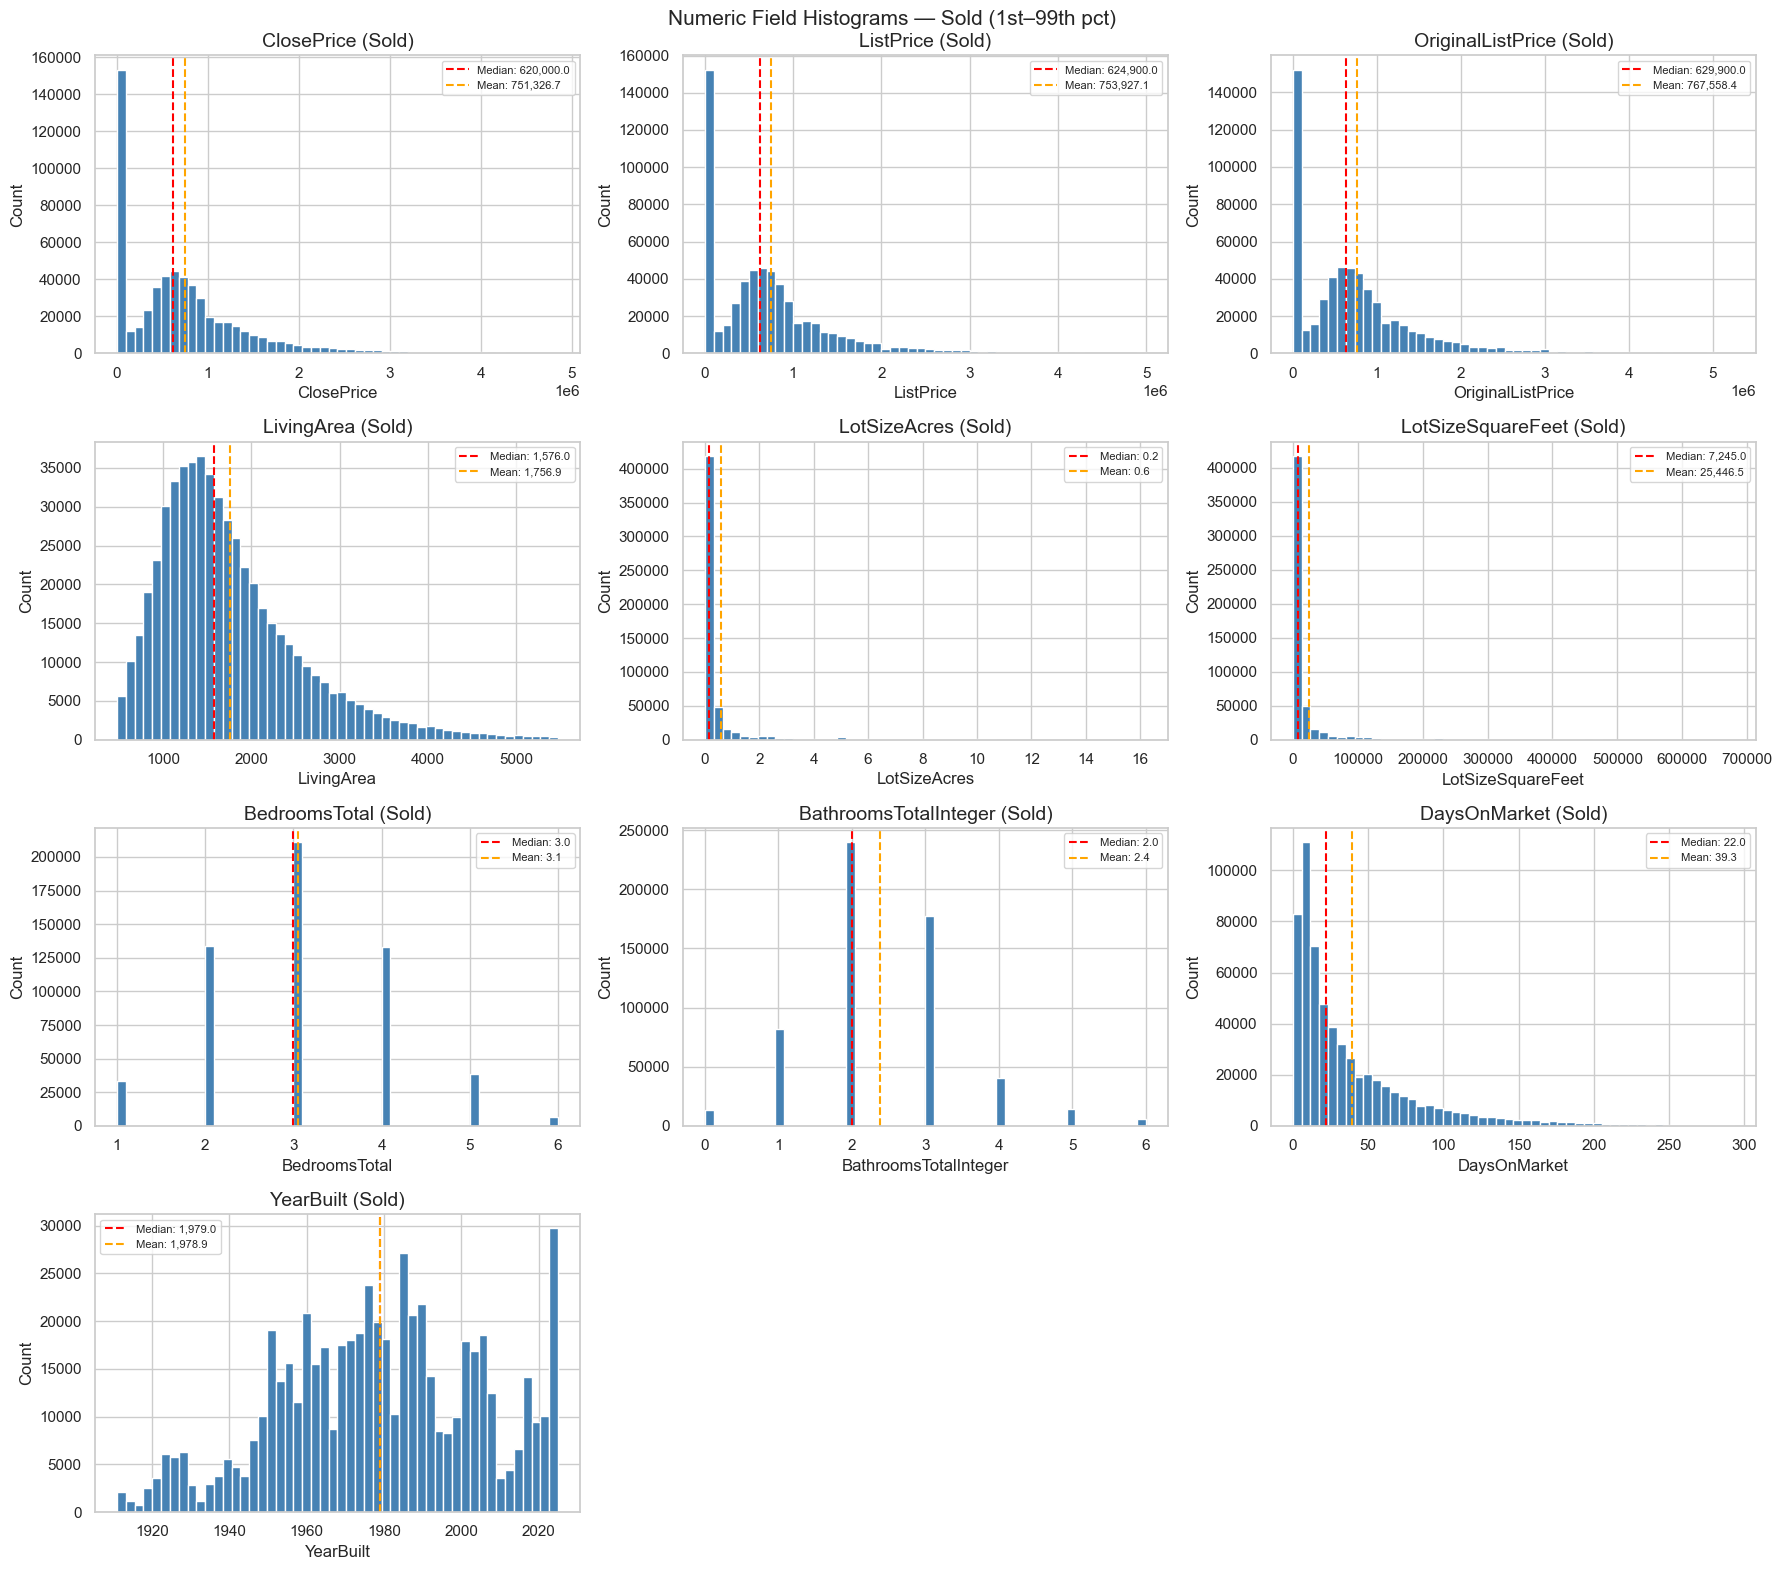

In [140]:
# Histograms for all numeric fields — SOLD
fields_sold = list(sold_num.keys())
ncols = 3
nrows = -(-len(fields_sold) // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, (col, series) in enumerate(sold_num.items()):
    data = series.dropna()
    data_c = data[(data >= data.quantile(0.01)) & (data <= data.quantile(0.99))]
    axes[i].hist(data_c, bins=50, color='steelblue', edgecolor='white')
    axes[i].axvline(data_c.median(), color='red',    linestyle='--', linewidth=1.5, label=f'Median: {data_c.median():,.1f}')
    axes[i].axvline(data_c.mean(),   color='orange', linestyle='--', linewidth=1.5, label=f'Mean: {data_c.mean():,.1f}')
    axes[i].set_title(f'{col} (Sold)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=8)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Numeric Field Histograms — Sold (1st–99th pct)', fontsize=15)
plt.tight_layout()
plt.show()

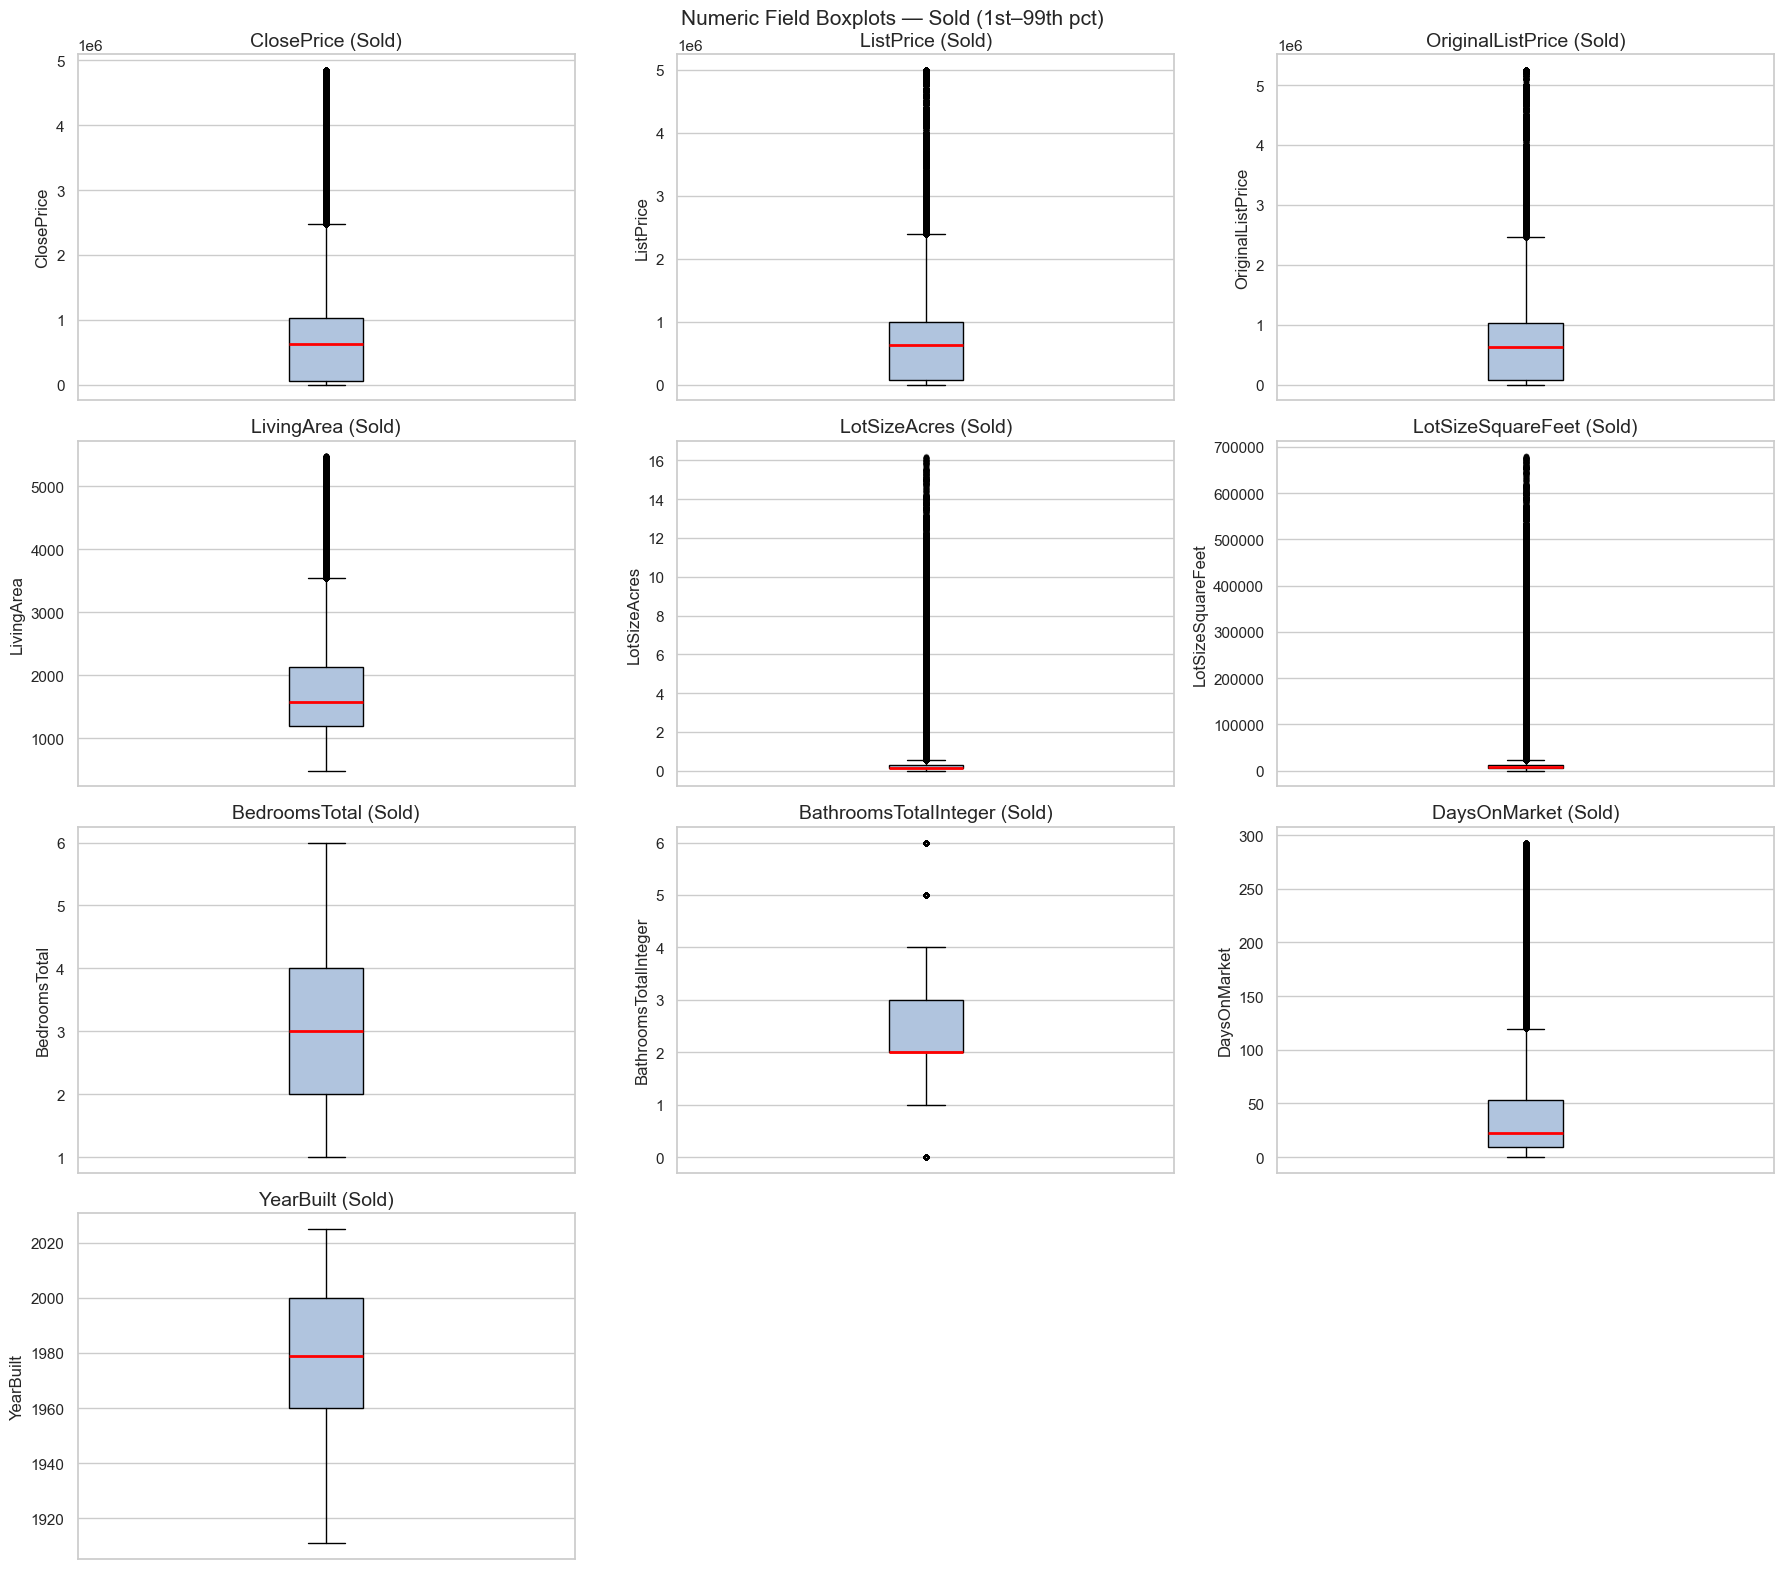

In [141]:
# Boxplots for all numeric fields — SOLD
fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
axes = axes.flatten()

for i, (col, series) in enumerate(sold_num.items()):
    data = series.dropna()
    data_c = data[(data >= data.quantile(0.01)) & (data <= data.quantile(0.99))]
    axes[i].boxplot(data_c, patch_artist=True,
                    boxprops=dict(facecolor='lightsteelblue'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='.', alpha=0.3))
    axes[i].set_title(f'{col} (Sold)')
    axes[i].set_ylabel(col)
    axes[i].set_xticks([])

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Numeric Field Boxplots — Sold (1st–99th pct)', fontsize=15)
plt.tight_layout()
plt.show()

## 5. Exploratative Questions (Pre-Clean EDA)
Answering the handbook questions sing raw data before any filtering.

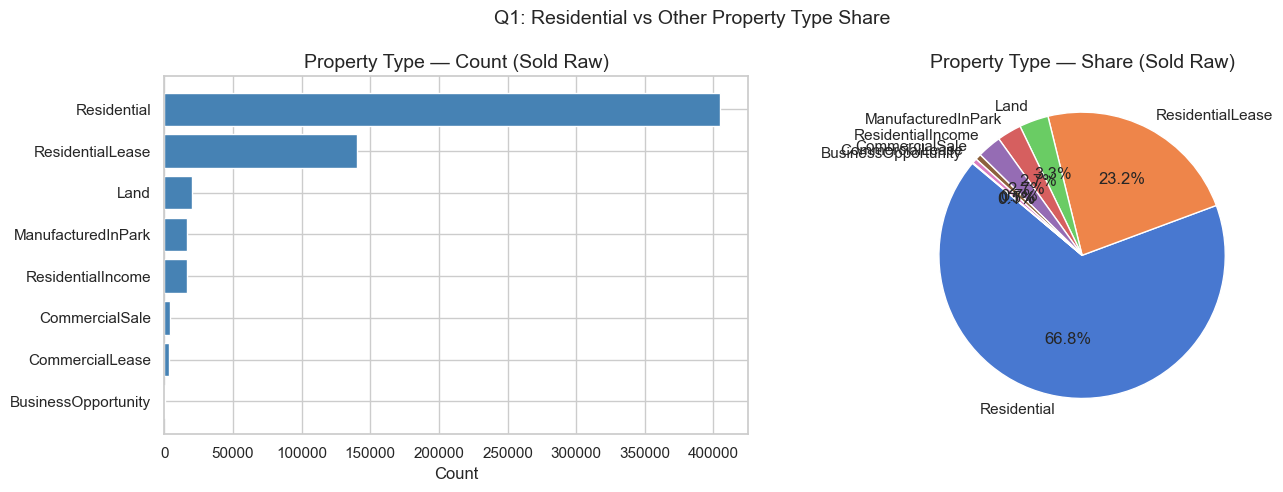

PropertyType
Residential            66.77
ResidentialLease       23.17
Land                    3.30
ManufacturedInPark      2.75
ResidentialIncome       2.73
CommercialSale          0.66
CommercialLease         0.54
BusinessOpportunity     0.07

Residential share: ~66.8%


In [142]:
# Q1: Residential vs other property type share
if 'PropertyType' in sold_raw.columns:
    pt_counts = sold_raw['PropertyType'].value_counts()
    pt_pct    = sold_raw['PropertyType'].value_counts(normalize=True).mul(100).round(2)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].barh(pt_counts.index[::-1], pt_counts.values[::-1], color='steelblue', edgecolor='white')
    axes[0].set_title('Property Type — Count (Sold Raw)')
    axes[0].set_xlabel('Count')

    axes[1].pie(pt_counts.values, labels=pt_counts.index, autopct='%1.1f%%', startangle=140)
    axes[1].set_title('Property Type — Share (Sold Raw)')

    plt.suptitle('Q1: Residential vs Other Property Type Share', fontsize=14)
    plt.tight_layout()
    plt.show()

    print(pt_pct.to_string())
    res_pct = pt_pct.get('Residential', pt_pct.get('residential', 0))
    print(f'\nResidential share: ~{res_pct:.1f}%')

In [143]:
# Q2: Median and average close prices
cp = pd.to_numeric(sold_raw['ClosePrice'], errors='coerce').dropna()
print(f'Q2: Close Price Statistics (Raw Sold)')
print(f'  Median Close Price: ${cp.median():,.0f}')
print(f'  Mean Close Price:   ${cp.mean():,.0f}')
print(f'  Std Dev:            ${cp.std():,.0f}')
print(f'  Min:                ${cp.min():,.0f}')
print(f'  Max:                ${cp.max():,.0f}')

Q2: Close Price Statistics (Raw Sold)
  Median Close Price: $620,000
  Mean Close Price:   $821,148
  Std Dev:            $1,709,588
  Min:                $0
  Max:                $748,655,000


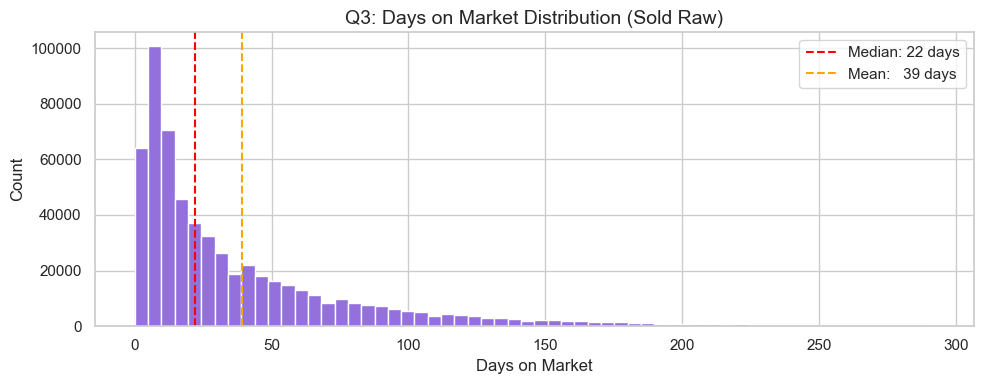

Median DOM: 22 | Mean: 39 | Std: 46
Homes sold in 0–7 days:   128,151  (21.3%)
Homes sold in 8–30 days:  227,631  (37.9%)
Homes sold in 31–90 days: 174,117  (29.0%)
Homes sold in 90+ days:   70,541  (11.7%)


In [144]:
# Q3: Days on Market distribution
dom = pd.to_numeric(sold_raw['DaysOnMarket'], errors='coerce').dropna() if 'DaysOnMarket' in sold_raw.columns else pd.Series([])
dom_c = dom[(dom >= 0) & (dom < dom.quantile(0.99))]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(dom_c, bins=60, color='mediumpurple', edgecolor='white')
ax.axvline(dom_c.median(), color='red',    linestyle='--', label=f'Median: {dom_c.median():.0f} days')
ax.axvline(dom_c.mean(),   color='orange', linestyle='--', label=f'Mean:   {dom_c.mean():.0f} days')
ax.set_title('Q3: Days on Market Distribution (Sold Raw)')
ax.set_xlabel('Days on Market')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Median DOM: {dom_c.median():.0f} | Mean: {dom_c.mean():.0f} | Std: {dom_c.std():.0f}')
print(f'Homes sold in 0–7 days:   {(dom_c <= 7).sum():,}  ({(dom_c <= 7).mean()*100:.1f}%)')
print(f'Homes sold in 8–30 days:  {((dom_c > 7) & (dom_c <= 30)).sum():,}  ({((dom_c > 7) & (dom_c <= 30)).mean()*100:.1f}%)')
print(f'Homes sold in 31–90 days: {((dom_c > 30) & (dom_c <= 90)).sum():,}  ({((dom_c > 30) & (dom_c <= 90)).mean()*100:.1f}%)')
print(f'Homes sold in 90+ days:   {(dom_c > 90).sum():,}  ({(dom_c > 90).mean()*100:.1f}%)')

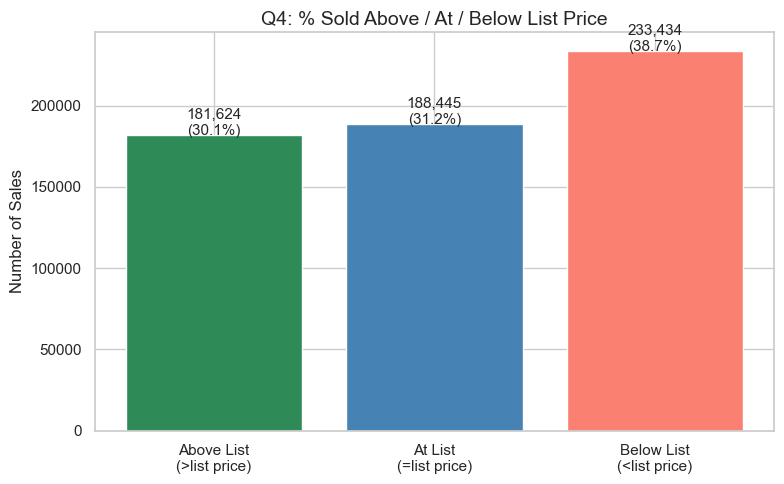

Above list: 181,624 (30.1%)
At list:    188,445    (31.2%)
Below list: 233,434 (38.7%)


In [145]:
# Q4: Percentage sold above vs below list price
cp_raw  = pd.to_numeric(sold_raw['ClosePrice'], errors='coerce')
lp_raw  = pd.to_numeric(sold_raw['ListPrice'],  errors='coerce')
stl_raw = (cp_raw / lp_raw).dropna()
stl_raw = stl_raw[(stl_raw > 0.5) & (stl_raw < 1.5)]

above = (stl_raw > 1.0).sum()
at    = (stl_raw == 1.0).sum()
below = (stl_raw < 1.0).sum()
total = len(stl_raw)

fig, ax = plt.subplots(figsize=(8, 5))
labels = ['Above List\n(>list price)', 'At List\n(=list price)', 'Below List\n(<list price)']
vals   = [above, at, below]
bars   = ax.bar(labels, vals, color=['seagreen','steelblue','salmon'], edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{v:,}\n({v/total*100:.1f}%)', ha='center', fontsize=11)
ax.set_title('Q4: % Sold Above / At / Below List Price')
ax.set_ylabel('Number of Sales')
plt.tight_layout()
plt.show()

print(f'Above list: {above:,} ({above/total*100:.1f}%)')
print(f'At list:    {at:,}    ({at/total*100:.1f}%)')
print(f'Below list: {below:,} ({below/total*100:.1f}%)')

In [146]:
# Q5: Date consistency check — close date before listing date
# Check within sold dataset if ListingContractDate is available
if 'CloseDate' in sold_raw.columns and 'ListingContractDate' in sold_raw.columns:
    cd = pd.to_datetime(sold_raw['CloseDate'],           errors='coerce')
    ld = pd.to_datetime(sold_raw['ListingContractDate'], errors='coerce')
    both_valid = cd.notna() & ld.notna()
    invalid    = (cd < ld) & both_valid
    print(f'Q5: Date Consistency Check')
    print(f'  Records with both dates valid: {both_valid.sum():,}')
    print(f'  Records where CloseDate < ListingContractDate (invalid): {invalid.sum():,}')
    print(f'  Invalid rate: {invalid.sum()/both_valid.sum()*100:.2f}%')
    if invalid.sum() > 0:
        print('  *** These records should be flagged or removed in cleaning.')
        print(sold_raw[invalid][['CloseDate','ListingContractDate']].head(5))
else:
    # Fallback: just check CloseDate range in sold
    cd = pd.to_datetime(sold_raw['CloseDate'], errors='coerce') if 'CloseDate' in sold_raw.columns else None
    if cd is not None:
        print(f'Q5: CloseDate range in Sold: {cd.min().date()} to {cd.max().date()}')
        print(f'    Invalid (NaT) CloseDates: {cd.isna().sum():,}')
    print('  Note: ListingContractDate not in sold dataset — cross-dataset date check not applicable.')

Q5: Date Consistency Check
  Records with both dates valid: 606,477
  Records where CloseDate < ListingContractDate (invalid): 139
  Invalid rate: 0.02%
  *** These records should be flagged or removed in cleaning.
      CloseDate ListingContractDate
7    2024-01-26          2024-02-29
9    2024-01-30          2024-02-27
27   2024-01-30          2024-01-31
69   2024-01-26          2024-01-29
124  2024-01-25          2024-01-26


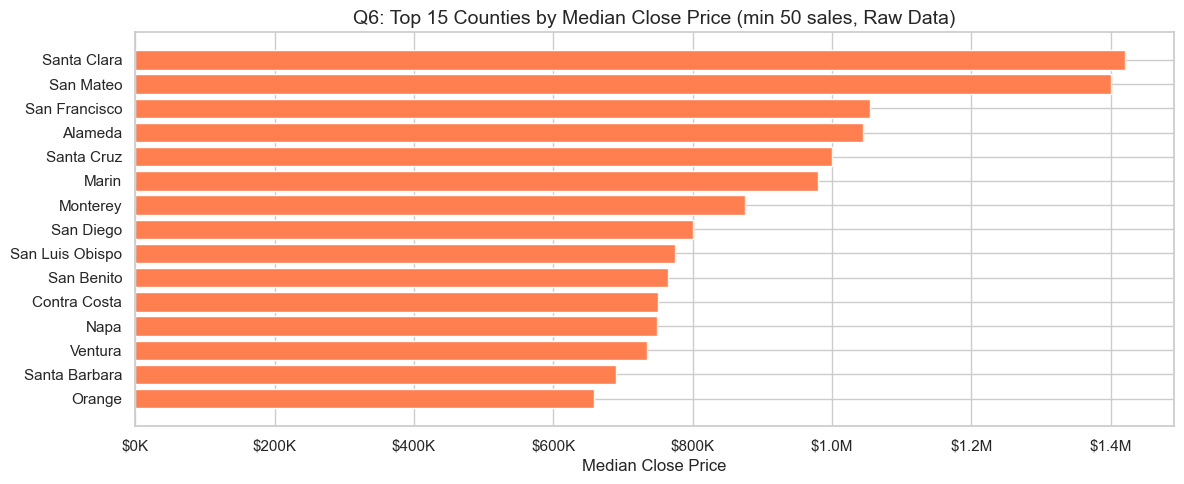

 CountyOrParish  MedianPrice  Count
    Santa Clara    1420000.0  17743
      San Mateo    1400000.0   8081
  San Francisco    1054000.0   1170
        Alameda    1045000.0  22146
     Santa Cruz    1000000.0   3544
          Marin     980000.0    179
       Monterey     875000.0   4270
      San Diego     800000.0  66547
San Luis Obispo     775000.0   7796
     San Benito     765000.0    869
   Contra Costa     750000.0  22052
           Napa     749543.5    152
        Ventura     735000.0  18768
  Santa Barbara     690000.0   2468
         Orange     659000.0  81021


In [147]:
# Q6: Which counties have the highest median prices?
if 'CountyOrParish' in sold_raw.columns and 'ClosePrice' in sold_raw.columns:
    county_raw = (
        sold_raw.assign(ClosePrice=pd.to_numeric(sold_raw['ClosePrice'], errors='coerce'))
        .groupby('CountyOrParish')
        .agg(MedianPrice=('ClosePrice','median'), Count=('ClosePrice','count'))
        .query('Count >= 50')
        .sort_values('MedianPrice', ascending=False)
        .head(15)
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.barh(county_raw['CountyOrParish'][::-1], county_raw['MedianPrice'][::-1], color='coral', edgecolor='white')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M' if x>=1e6 else f'${x/1e3:.0f}K'))
    ax.set_title('Q6: Top 15 Counties by Median Close Price (min 50 sales, Raw Data)')
    ax.set_xlabel('Median Close Price')
    plt.tight_layout()
    plt.show()

    print(county_raw[['CountyOrParish','MedianPrice','Count']].to_string(index=False))

---
# Weeks 4–5 — Data Cleaning & Preparation
Raw MLS data contains formatting inconsistencies, missing values, and fields that need transformation before analysis.
This phase produces a clean, analysis-ready dataset and documents every transformation made and why.

## 6. Date Field Conversion
Convert all date fields to datetime format: `CloseDate`, `PurchaseContractDate`, `ListingContractDate`, `ContractStatusChangeDate`.
Datetime typing enables date arithmetic, timeline validation, and time-series analysis.

In [148]:
date_fields = ['CloseDate', 'PurchaseContractDate', 'ListingContractDate', 'ContractStatusChangeDate']

print('=== SOLD — Date Field Conversion ===')
for col in date_fields:
    if col in sold_raw.columns:
        before_nulls = sold_raw[col].isna().sum()
        sold_raw[col] = pd.to_datetime(sold_raw[col], errors='coerce')
        after_nulls  = sold_raw[col].isna().sum()
        new_nulls    = after_nulls - before_nulls
        print(f'  {col:<30} dtype: {sold_raw[col].dtype}  |  unparseable → NaT: {new_nulls:,}')
    else:
        print(f'  {col:<30} NOT FOUND in sold dataset')

print('\n=== LISTING — Date Field Conversion ===')
for col in date_fields:
    if col in listing_raw.columns:
        before_nulls = listing_raw[col].isna().sum()
        listing_raw[col] = pd.to_datetime(listing_raw[col], errors='coerce')
        after_nulls  = listing_raw[col].isna().sum()
        new_nulls    = after_nulls - before_nulls
        print(f'  {col:<30} dtype: {listing_raw[col].dtype}  |  unparseable → NaT: {new_nulls:,}')
    else:
        print(f'  {col:<30} NOT FOUND in listing dataset')

=== SOLD — Date Field Conversion ===
  CloseDate                      dtype: datetime64[ns]  |  unparseable → NaT: 0
  PurchaseContractDate           dtype: datetime64[ns]  |  unparseable → NaT: 0
  ListingContractDate            dtype: datetime64[ns]  |  unparseable → NaT: 0
  ContractStatusChangeDate       dtype: datetime64[ns]  |  unparseable → NaT: 0

=== LISTING — Date Field Conversion ===
  CloseDate                      dtype: datetime64[ns]  |  unparseable → NaT: 1
  PurchaseContractDate           dtype: datetime64[ns]  |  unparseable → NaT: 0
  ListingContractDate            dtype: datetime64[ns]  |  unparseable → NaT: 0
  ContractStatusChangeDate       dtype: datetime64[ns]  |  unparseable → NaT: 1


## 7. Column Selection & Type Enforcement
Keep only relevant columns (removing unnecessary/redundant metadata), then enforce correct numeric types.
This reduces noise and ensures downstream calculations work correctly.

In [149]:
# ── Columns to keep ──
sold_keep = [
    'OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'ListOfficeName',
    'ListPrice', 'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger',
    'LivingArea', 'PropertyType', 'PropertySubType', 'DaysOnMarket',
    'ClosePrice', 'CloseDate', 'PurchaseContractDate', 'ContractStatusChangeDate',
    'BuyerAgentFirstName', 'BuyerAgentLastName', 'BuyerOfficeName',
    'City', 'PostalCode', 'CountyOrParish', 'Latitude', 'Longitude', 'UnparsedAddress'
]
listing_keep = [
    'OriginalListPrice', 'ListAgentFirstName', 'ListAgentLastName', 'ListPrice',
    'LotSizeSquareFeet', 'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea',
    'PropertyType', 'PropertySubType', 'DaysOnMarket', 'City', 'PostalCode',
    'CountyOrParish', 'Latitude', 'Longitude', 'UnparsedAddress',
    'ListOfficeName', 'MlsStatus', 'ListingContractDate', 'PurchaseContractDate'
]

sold_keep    = [c for c in sold_keep    if c in sold_raw.columns]
listing_keep = [c for c in listing_keep if c in listing_raw.columns]

sold_work    = sold_raw[sold_keep].copy()
listing_work = listing_raw[listing_keep].copy()

print(f'SOLD    — kept {len(sold_keep)} of {sold_raw.shape[1]} columns  '
      f'(dropped {sold_raw.shape[1] - len(sold_keep)} metadata/redundant cols)')
print(f'LISTING — kept {len(listing_keep)} of {listing_raw.shape[1]} columns  '
      f'(dropped {listing_raw.shape[1] - len(listing_keep)} metadata/redundant cols)')

SOLD    — kept 25 of 81 columns  (dropped 56 metadata/redundant cols)
LISTING — kept 21 of 71 columns  (dropped 50 metadata/redundant cols)


In [150]:
# ── Enforce numeric types ──
num_cols_sold = [
    'OriginalListPrice', 'ListPrice', 'ClosePrice', 'LotSizeSquareFeet',
    'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'DaysOnMarket',
    'Latitude', 'Longitude'
]
num_cols_listing = [
    'OriginalListPrice', 'ListPrice', 'LotSizeSquareFeet',
    'BedroomsTotal', 'BathroomsTotalInteger', 'LivingArea', 'DaysOnMarket',
    'Latitude', 'Longitude'
]

print('SOLD — Numeric type enforcement:')
for c in num_cols_sold:
    if c in sold_work.columns:
        before = sold_work[c].dtype
        sold_work[c] = pd.to_numeric(sold_work[c], errors='coerce')
        print(f'  {c:<30} {str(before):>10} → {sold_work[c].dtype}')

print('\nLISTING — Numeric type enforcement:')
for c in num_cols_listing:
    if c in listing_work.columns:
        before = listing_work[c].dtype
        listing_work[c] = pd.to_numeric(listing_work[c], errors='coerce')
        print(f'  {c:<30} {str(before):>10} → {listing_work[c].dtype}')

SOLD — Numeric type enforcement:
  OriginalListPrice                 float64 → float64
  ListPrice                         float64 → float64
  ClosePrice                        float64 → float64
  LotSizeSquareFeet                 float64 → float64
  BedroomsTotal                     float64 → float64
  BathroomsTotalInteger             float64 → float64
  LivingArea                        float64 → float64
  DaysOnMarket                        int64 → int64
  Latitude                          float64 → float64
  Longitude                         float64 → float64

LISTING — Numeric type enforcement:
  OriginalListPrice                 float64 → float64
  ListPrice                         float64 → float64
  LotSizeSquareFeet                 float64 → float64
  BedroomsTotal                     float64 → float64
  BathroomsTotalInteger             float64 → float64
  LivingArea                        float64 → float64
  DaysOnMarket                        int64 → int64
  Latitude      

## 8. Invalid Numeric Value Flags & Removal
Flag then remove records with physically impossible values:
- `ClosePrice <= 0` — a sale must have a positive price
- `LivingArea <= 0` — a property must have positive square footage
- `DaysOnMarket < 0` — negative DOM is impossible
- `BedroomsTotal < 0` or `BathroomsTotalInteger < 0` — negative rooms are impossible

We flag first so we can count and inspect, then drop.

In [151]:
rows_before_invalid = len(sold_work)

# ── Flag invalid records ──
sold_work['flag_invalid_close_price']  = sold_work['ClosePrice'].le(0)   if 'ClosePrice'            in sold_work.columns else False
sold_work['flag_invalid_living_area']  = sold_work['LivingArea'].le(0)   if 'LivingArea'            in sold_work.columns else False
sold_work['flag_invalid_dom']          = sold_work['DaysOnMarket'].lt(0) if 'DaysOnMarket'          in sold_work.columns else False
sold_work['flag_invalid_bedrooms']     = sold_work['BedroomsTotal'].lt(0)         if 'BedroomsTotal'         in sold_work.columns else False
sold_work['flag_invalid_bathrooms']    = sold_work['BathroomsTotalInteger'].lt(0) if 'BathroomsTotalInteger' in sold_work.columns else False

# ── Summary of flags ──
flag_cols = ['flag_invalid_close_price','flag_invalid_living_area',
             'flag_invalid_dom','flag_invalid_bedrooms','flag_invalid_bathrooms']
print('SOLD — Invalid Numeric Flags (before removal):')
print(f'  {"Flag":<35} {"Count":>8} {"Rate":>8}')
print('  ' + '-'*53)
for f in flag_cols:
    if f in sold_work.columns:
        n = sold_work[f].sum()
        print(f'  {f:<35} {n:>8,} {n/len(sold_work)*100:>7.2f}%')

any_invalid = sold_work[flag_cols].any(axis=1)
print(f'\n  Total rows with ANY invalid numeric value: {any_invalid.sum():,} ({any_invalid.mean()*100:.2f}%)')

SOLD — Invalid Numeric Flags (before removal):
  Flag                                   Count     Rate
  -----------------------------------------------------
  flag_invalid_close_price                  34    0.01%
  flag_invalid_living_area                 496    0.08%
  flag_invalid_dom                          55    0.01%
  flag_invalid_bedrooms                      0    0.00%
  flag_invalid_bathrooms                     0    0.00%

  Total rows with ANY invalid numeric value: 584 (0.10%)


In [152]:
# Do the same for listing
listing_work['flag_invalid_list_price']  = listing_work['ListPrice'].le(0)    if 'ListPrice'             in listing_work.columns else False
listing_work['flag_invalid_living_area'] = listing_work['LivingArea'].le(0)   if 'LivingArea'            in listing_work.columns else False
listing_work['flag_invalid_dom']         = listing_work['DaysOnMarket'].lt(0) if 'DaysOnMarket'          in listing_work.columns else False
listing_work['flag_invalid_bedrooms']    = listing_work['BedroomsTotal'].lt(0)         if 'BedroomsTotal'         in listing_work.columns else False
listing_work['flag_invalid_bathrooms']   = listing_work['BathroomsTotalInteger'].lt(0) if 'BathroomsTotalInteger' in listing_work.columns else False

flag_cols_l = ['flag_invalid_list_price','flag_invalid_living_area',
               'flag_invalid_dom','flag_invalid_bedrooms','flag_invalid_bathrooms']
print('LISTING — Invalid Numeric Flags:')
print(f'  {"Flag":<35} {"Count":>8} {"Rate":>8}')
print('  ' + '-'*53)
for f in flag_cols_l:
    if f in listing_work.columns:
        n = listing_work[f].sum()
        print(f'  {f:<35} {n:>8,} {n/len(listing_work)*100:>7.2f}%')

LISTING — Invalid Numeric Flags:
  Flag                                   Count     Rate
  -----------------------------------------------------
  flag_invalid_list_price                    5    0.00%
  flag_invalid_living_area                 617    0.09%
  flag_invalid_dom                          50    0.01%
  flag_invalid_bedrooms                      0    0.00%
  flag_invalid_bathrooms                     0    0.00%


In [153]:
# ── Remove invalid rows ──
sold_work    = sold_work[~sold_work[flag_cols].any(axis=1)].copy()
listing_work = listing_work[~listing_work[flag_cols_l].any(axis=1)].copy()

# Drop flag columns now that removal is done
sold_work.drop(columns=flag_cols,   inplace=True)
listing_work.drop(columns=flag_cols_l, inplace=True)

print(f'SOLD    — rows before: {rows_before_invalid:,}  →  after removing invalid numerics: {len(sold_work):,}  (dropped {rows_before_invalid - len(sold_work):,})')
print(f'LISTING — rows before: {listing_raw.shape[0]:,}  →  after removing invalid numerics: {len(listing_work):,}  (dropped {listing_raw.shape[0] - len(listing_work):,})')

SOLD    — rows before: 606,568  →  after removing invalid numerics: 605,984  (dropped 584)
LISTING — rows before: 675,678  →  after removing invalid numerics: 675,006  (dropped 672)


## 9. Missing Value Handling
Strategy:
- Drop rows missing **critical** fields: `ClosePrice`, `ListPrice`, `OriginalListPrice`, `CloseDate`
- Fill remaining numeric nulls with **column median** (robust to outliers)
- Fill categorical nulls with `'Unknown'` to preserve rows
- Cap outliers on price and size fields using IQR method (sold only — listing prices not yet realized)

In [154]:
def cap_outliers(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    df[col] = df[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
    return df

# ── SOLD: drop rows missing critical fields ──
rows_before_drop = len(sold_work)
sold_work = sold_work.dropna(subset=['OriginalListPrice','ListPrice','ClosePrice','CloseDate'])
sold_work = sold_work.drop_duplicates()
print(f'SOLD — dropped {rows_before_drop - len(sold_work):,} rows missing critical price/date fields')
print(f'       remaining: {len(sold_work):,}')

# ── LISTING: drop rows missing critical fields ──
rows_before_drop_l = len(listing_work)
listing_work = listing_work.dropna(subset=['OriginalListPrice','ListPrice'])
listing_work = listing_work.drop_duplicates()
print(f'\nLISTING — dropped {rows_before_drop_l - len(listing_work):,} rows missing critical price fields')
print(f'          remaining: {len(listing_work):,}')

SOLD — dropped 1,936 rows missing critical price/date fields
       remaining: 604,048

LISTING — dropped 2,438 rows missing critical price fields
          remaining: 672,568


In [155]:
# ── Fill remaining numeric nulls with median ──
fill_num_sold    = ['LotSizeSquareFeet','BedroomsTotal','BathroomsTotalInteger','LivingArea','DaysOnMarket']
fill_num_listing = ['LotSizeSquareFeet','BedroomsTotal','BathroomsTotalInteger','LivingArea','DaysOnMarket']

print('SOLD — Median fills:')
for c in fill_num_sold:
    if c in sold_work.columns and sold_work[c].isna().any():
        n = sold_work[c].isna().sum()
        med = sold_work[c].median()
        sold_work[c] = sold_work[c].fillna(med)
        print(f'  {c:<30} filled {n:,} nulls with median={med:.1f}')

print('\nLISTING — Median fills:')
for c in fill_num_listing:
    if c in listing_work.columns and listing_work[c].isna().any():
        n = listing_work[c].isna().sum()
        med = listing_work[c].median()
        listing_work[c] = listing_work[c].fillna(med)
        print(f'  {c:<30} filled {n:,} nulls with median={med:.1f}')

SOLD — Median fills:
  LotSizeSquareFeet              filled 56,156 nulls with median=7295.0
  BedroomsTotal                  filled 39,934 nulls with median=3.0
  BathroomsTotalInteger          filled 27,314 nulls with median=2.0
  LivingArea                     filled 42,620 nulls with median=1577.0

LISTING — Median fills:
  LotSizeSquareFeet              filled 61,407 nulls with median=7405.0
  BedroomsTotal                  filled 59,764 nulls with median=3.0
  BathroomsTotalInteger          filled 40,951 nulls with median=2.0
  LivingArea                     filled 62,668 nulls with median=1584.0


In [156]:
# ── Fill categorical nulls with Unknown ──
str_fill_sold = [
    'ListAgentFirstName','ListAgentLastName','ListOfficeName',
    'BuyerAgentFirstName','BuyerAgentLastName','BuyerOfficeName',
    'PropertyType','PropertySubType','City','CountyOrParish','UnparsedAddress'
]
str_fill_listing = [
    'ListAgentFirstName','ListAgentLastName','ListOfficeName',
    'PropertyType','PropertySubType','City','CountyOrParish',
    'UnparsedAddress','MlsStatus'
]
str_fmt_cols = [
    'ListAgentFirstName','ListAgentLastName','ListOfficeName',
    'BuyerAgentFirstName','BuyerAgentLastName','BuyerOfficeName',
    'PropertyType','PropertySubType','City','CountyOrParish','MlsStatus'
]

for c in str_fill_sold:
    if c in sold_work.columns:    sold_work[c]    = sold_work[c].fillna('Unknown')
for c in str_fill_listing:
    if c in listing_work.columns: listing_work[c] = listing_work[c].fillna('Unknown')
for c in str_fmt_cols:
    if c in sold_work.columns:    sold_work[c]    = sold_work[c].astype(str).str.strip().str.title()
    if c in listing_work.columns: listing_work[c] = listing_work[c].astype(str).str.strip().str.title()

# ── Cap outliers on sold price & size fields ──
for c in ['OriginalListPrice','ListPrice','ClosePrice','LotSizeSquareFeet','LivingArea']:
    if c in sold_work.columns: sold_work = cap_outliers(sold_work, c)

# ── Derived columns ──
sold_work['SaleToListRatio'] = sold_work['ClosePrice'] / sold_work['ListPrice']
sold_work['PricePerSqFt']    = sold_work['ClosePrice'] / sold_work['LivingArea']
sold_work['PriceDrop']       = sold_work['OriginalListPrice'] - sold_work['ListPrice']
sold_work['PriceDropPct']    = (sold_work['PriceDrop'] / sold_work['OriginalListPrice']) * 100
sold_work['CloseMonth']      = sold_work['CloseDate'].dt.to_period('M')
sold_work['CloseYear']       = sold_work['CloseDate'].dt.year

listing_work['PriceDrop']    = listing_work['OriginalListPrice'] - listing_work['ListPrice']
listing_work['PriceDropPct'] = (listing_work['PriceDrop'] / listing_work['OriginalListPrice']) * 100

print('Categorical fills, string standardization, outlier capping, and derived columns complete ✓')

Categorical fills, string standardization, outlier capping, and derived columns complete ✓


## 10. Date Consistency Checks & Flags
Validate the logical order of date fields:
`ListingContractDate` → `PurchaseContractDate` → `CloseDate`

Create three boolean flag columns:
- `listing_after_close_flag` — ListingContractDate > CloseDate (impossible)
- `purchase_after_close_flag` — PurchaseContractDate > CloseDate (impossible)
- `negative_timeline_flag` — any date ordering violation

In [157]:
# ── Apply to sold_work ──
has_lcd = 'ListingContractDate' in sold_work.columns
has_pcd = 'PurchaseContractDate' in sold_work.columns
has_cd  = 'CloseDate' in sold_work.columns

# listing_after_close_flag
if has_lcd and has_cd:
    sold_work['listing_after_close_flag'] = (
        sold_work['ListingContractDate'].notna() &
        sold_work['CloseDate'].notna() &
        (sold_work['ListingContractDate'] > sold_work['CloseDate'])
    )
else:
    sold_work['listing_after_close_flag'] = False

# purchase_after_close_flag
if has_pcd and has_cd:
    sold_work['purchase_after_close_flag'] = (
        sold_work['PurchaseContractDate'].notna() &
        sold_work['CloseDate'].notna() &
        (sold_work['PurchaseContractDate'] > sold_work['CloseDate'])
    )
else:
    sold_work['purchase_after_close_flag'] = False

# negative_timeline_flag — any violation
sold_work['negative_timeline_flag'] = (
    sold_work['listing_after_close_flag'] |
    sold_work['purchase_after_close_flag']
)

# ── Summary ──
date_flags = ['listing_after_close_flag','purchase_after_close_flag','negative_timeline_flag']
print('SOLD — Date Consistency Flag Summary:')
print(f'  {"Flag":<35} {"Count":>8} {"Rate":>8}')
print('  ' + '-'*53)
for f in date_flags:
    n = sold_work[f].sum()
    print(f'  {f:<35} {n:>8,} {n/len(sold_work)*100:>7.3f}%')

print('\nSample of flagged records (negative_timeline_flag):')
flag_cols_show = [c for c in ['ListingContractDate','PurchaseContractDate','CloseDate'] if c in sold_work.columns]
print(sold_work[sold_work['negative_timeline_flag']][flag_cols_show].head(5).to_string())

SOLD — Date Consistency Flag Summary:
  Flag                                   Count     Rate
  -----------------------------------------------------
  listing_after_close_flag                   0   0.000%
  purchase_after_close_flag                152   0.025%
  negative_timeline_flag                   152   0.025%

Sample of flagged records (negative_timeline_flag):
     PurchaseContractDate  CloseDate
156            2024-01-28 2024-01-24
469            2024-02-15 2024-01-15
620            2024-01-15 2024-01-14
699            2024-01-14 2024-01-13
1743           2024-01-11 2024-01-04


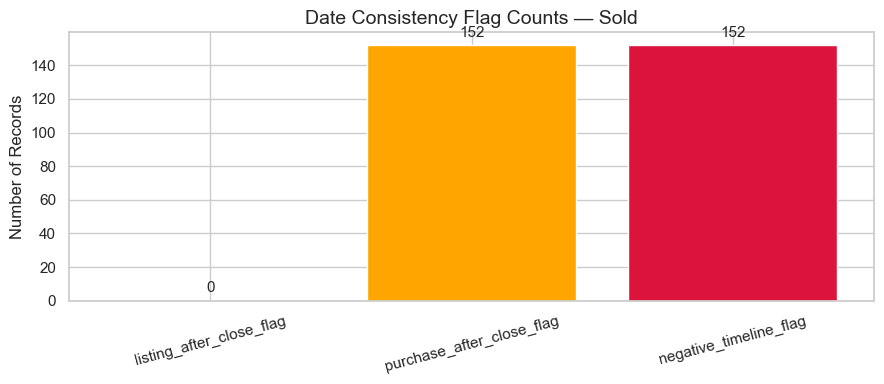


Note: flagged records are RETAINED with flags — analyst can choose to filter downstream.


In [158]:
# Visualize date flag counts
flag_counts = {f: sold_work[f].sum() for f in date_flags}

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(list(flag_counts.keys()), list(flag_counts.values()),
              color=['salmon','orange','crimson'], edgecolor='white')
for bar, v in zip(bars, flag_counts.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f'{v:,}', ha='center', fontsize=11)
ax.set_title('Date Consistency Flag Counts — Sold')
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

print('\nNote: flagged records are RETAINED with flags — analyst can choose to filter downstream.')

## 11. Geographic Data Quality Checks
Flag records with coordinate problems:
- `geo_flag_missing` — Latitude or Longitude is null
- `geo_flag_zero` — Latitude = 0 or Longitude = 0 (sentinel null values)
- `geo_flag_wrong_sign` — Longitude > 0 (California coords must be negative)
- `geo_flag_out_of_bounds` — outside California bounding box (lat 32–42, lon -125 to -114)

In [159]:
def add_geo_flags(df, label):
    has_lat = 'Latitude'  in df.columns
    has_lon = 'Longitude' in df.columns

    if has_lat and has_lon:
        df['geo_flag_missing']     = df['Latitude'].isna() | df['Longitude'].isna()
        df['geo_flag_zero']        = (df['Latitude'] == 0) | (df['Longitude'] == 0)
        df['geo_flag_wrong_sign']  = df['Longitude'] > 0          # CA longitude must be negative
        df['geo_flag_out_of_bounds'] = (
            (df['Latitude']  < 32)  | (df['Latitude']  > 42) |
            (df['Longitude'] < -125) | (df['Longitude'] > -114)
        ) & ~df['geo_flag_missing']
        df['geo_flag_any'] = (
            df['geo_flag_missing'] | df['geo_flag_zero'] |
            df['geo_flag_wrong_sign'] | df['geo_flag_out_of_bounds']
        )
    else:
        for f in ['geo_flag_missing','geo_flag_zero','geo_flag_wrong_sign',
                  'geo_flag_out_of_bounds','geo_flag_any']:
            df[f] = False

    geo_flags = ['geo_flag_missing','geo_flag_zero','geo_flag_wrong_sign',
                 'geo_flag_out_of_bounds','geo_flag_any']
    print(f'\n=== {label} — Geographic Data Quality Summary ===')
    print(f'  {"Flag":<30} {"Count":>8} {"Rate":>8}')
    print('  ' + '-'*48)
    for f in geo_flags:
        n = int(df[f].sum())
        print(f'  {f:<30} {n:>8,} {n/len(df)*100:>7.2f}%')
    return df

sold_work    = add_geo_flags(sold_work,    'SOLD')
listing_work = add_geo_flags(listing_work, 'LISTING')


=== SOLD — Geographic Data Quality Summary ===
  Flag                              Count     Rate
  ------------------------------------------------
  geo_flag_missing                 70,539   11.68%
  geo_flag_zero                        49    0.01%
  geo_flag_wrong_sign                  68    0.01%
  geo_flag_out_of_bounds              184    0.03%
  geo_flag_any                     70,723   11.71%

=== LISTING — Geographic Data Quality Summary ===
  Flag                              Count     Rate
  ------------------------------------------------
  geo_flag_missing                 65,538    9.74%
  geo_flag_zero                        71    0.01%
  geo_flag_wrong_sign                 107    0.02%
  geo_flag_out_of_bounds              302    0.04%
  geo_flag_any                     65,840    9.79%


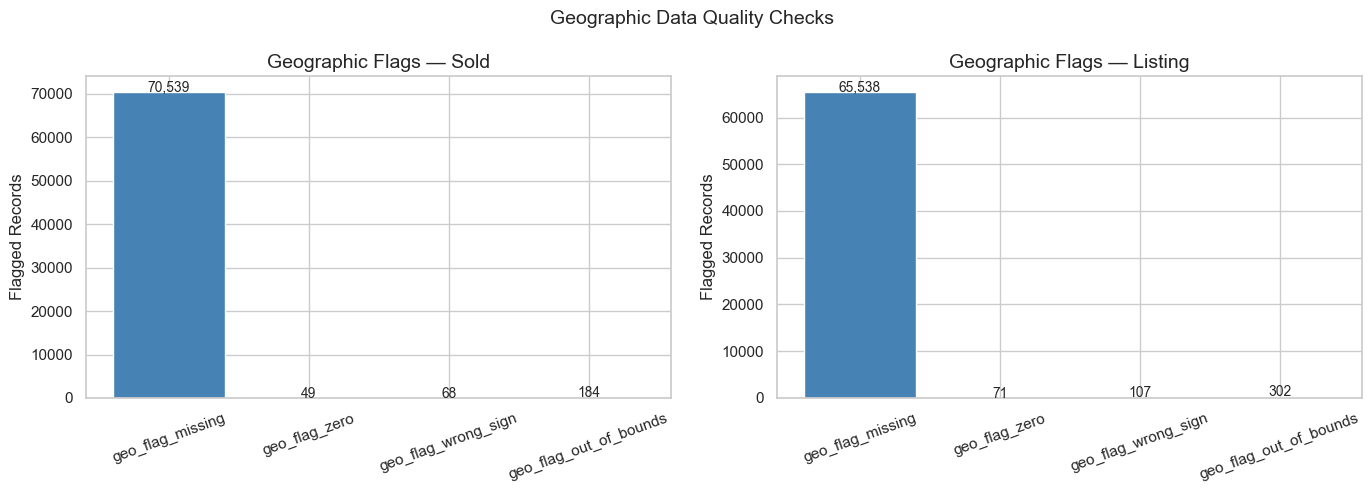


Note: geo flags are retained as columns — records are NOT dropped.
Analysts should exclude geo-flagged records from any map/spatial analysis.


In [160]:
# Visualize geo flags — sold
geo_flag_cols = ['geo_flag_missing','geo_flag_zero','geo_flag_wrong_sign','geo_flag_out_of_bounds']
geo_counts_s  = {f: int(sold_work[f].sum())    for f in geo_flag_cols if f in sold_work.columns}
geo_counts_l  = {f: int(listing_work[f].sum()) for f in geo_flag_cols if f in listing_work.columns}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, counts, label in [(axes[0], geo_counts_s, 'Sold'), (axes[1], geo_counts_l, 'Listing')]:
    bars = ax.bar(list(counts.keys()), list(counts.values()), color='steelblue', edgecolor='white')
    for bar, v in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v:,}', ha='center', fontsize=10)
    ax.set_title(f'Geographic Flags — {label}')
    ax.set_ylabel('Flagged Records')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Geographic Data Quality Checks', fontsize=14)
plt.tight_layout()
plt.show()

print('\nNote: geo flags are retained as columns — records are NOT dropped.')
print('Analysts should exclude geo-flagged records from any map/spatial analysis.')

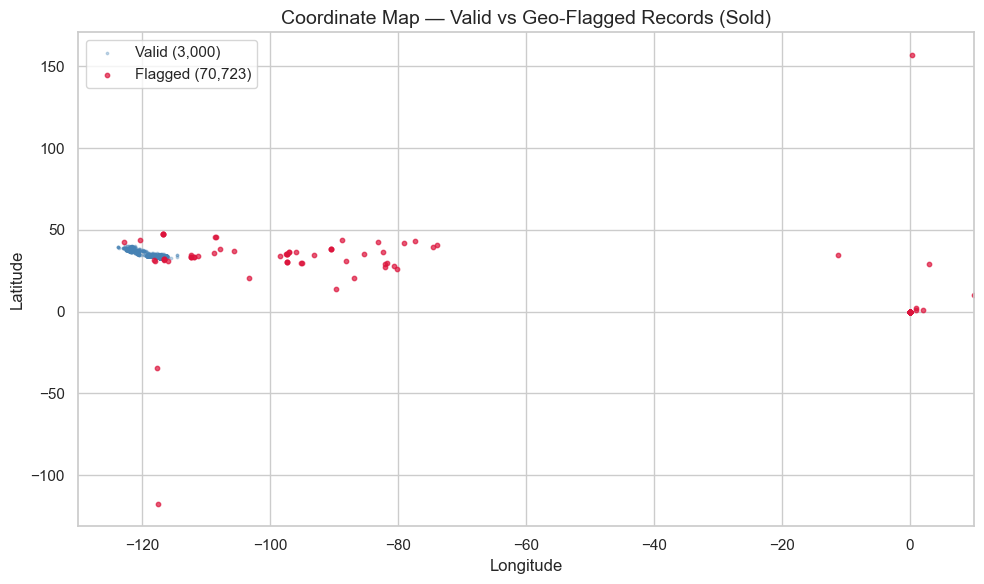

In [161]:
# Scatter: valid vs flagged coords (sold)
if 'Latitude' in sold_work.columns and 'Longitude' in sold_work.columns:
    valid   = sold_work[~sold_work['geo_flag_any']].sample(min(3000, (~sold_work['geo_flag_any']).sum()), random_state=42)
    flagged = sold_work[sold_work['geo_flag_any']]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(valid['Longitude'],   valid['Latitude'],   s=3,  alpha=0.3, color='steelblue', label=f'Valid ({len(valid):,})')
    ax.scatter(flagged['Longitude'], flagged['Latitude'], s=10, alpha=0.7, color='crimson',   label=f'Flagged ({len(flagged):,})')
    ax.set_xlim(-130, 10)
    ax.set_title('Coordinate Map — Valid vs Geo-Flagged Records (Sold)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 12. Before/After Summary & Data Type Confirmation
Document every transformation with row counts, and confirm final data types.

In [162]:
print('=' * 65)
print('   WEEKS 4-5 CLEANING SUMMARY — SOLD DATASET')
print('=' * 65)
print(f'  Raw rows loaded              : {sold_raw.shape[0]:>10,}')
print(f'  After invalid numeric removal: {rows_before_drop:>10,}  (dropped {sold_raw.shape[0] - rows_before_drop:,})')
print(f'  After missing critical fields: {len(sold_work):>10,}  (dropped {rows_before_drop - len(sold_work):,})')
print(f'  Final clean rows             : {len(sold_work):>10,}')
print(f'  Final columns                : {sold_work.shape[1]:>10}')
print()
print(f'  Date consistency flags')
for f in ['listing_after_close_flag','purchase_after_close_flag','negative_timeline_flag']:
    if f in sold_work.columns:
        print(f'    {f:<35}: {sold_work[f].sum():,}')
print()
print(f'  Geographic flags')
for f in ['geo_flag_missing','geo_flag_zero','geo_flag_wrong_sign','geo_flag_out_of_bounds','geo_flag_any']:
    if f in sold_work.columns:
        print(f'    {f:<35}: {int(sold_work[f].sum()):,}')
print('=' * 65)

   WEEKS 4-5 CLEANING SUMMARY — SOLD DATASET
  Raw rows loaded              :    606,568
  After invalid numeric removal:    605,984  (dropped 584)
  After missing critical fields:    604,048  (dropped 1,936)
  Final clean rows             :    604,048
  Final columns                :         39

  Date consistency flags
    listing_after_close_flag           : 0
    purchase_after_close_flag          : 152
    negative_timeline_flag             : 152

  Geographic flags
    geo_flag_missing                   : 70,539
    geo_flag_zero                      : 49
    geo_flag_wrong_sign                : 68
    geo_flag_out_of_bounds             : 184
    geo_flag_any                       : 70,723


In [163]:
print('=' * 65)
print('   WEEKS 4-5 CLEANING SUMMARY — LISTING DATASET')
print('=' * 65)
print(f'  Raw rows loaded              : {listing_raw.shape[0]:>10,}')
print(f'  After invalid numeric removal: {rows_before_drop_l:>10,}  (dropped {listing_raw.shape[0] - rows_before_drop_l:,})')
print(f'  After missing critical fields: {len(listing_work):>10,}  (dropped {rows_before_drop_l - len(listing_work):,})')
print(f'  Final clean rows             : {len(listing_work):>10,}')
print(f'  Final columns                : {listing_work.shape[1]:>10}')
print()
print(f'  Geographic flags')
for f in ['geo_flag_missing','geo_flag_zero','geo_flag_wrong_sign','geo_flag_out_of_bounds','geo_flag_any']:
    if f in listing_work.columns:
        print(f'    {f:<35}: {int(listing_work[f].sum()):,}')
print('=' * 65)

   WEEKS 4-5 CLEANING SUMMARY — LISTING DATASET
  Raw rows loaded              :    675,678
  After invalid numeric removal:    675,006  (dropped 672)
  After missing critical fields:    672,568  (dropped 2,438)
  Final clean rows             :    672,568
  Final columns                :         28

  Geographic flags
    geo_flag_missing                   : 65,538
    geo_flag_zero                      : 71
    geo_flag_wrong_sign                : 107
    geo_flag_out_of_bounds             : 302
    geo_flag_any                       : 65,840


In [164]:
# ── Data type confirmation ──
print('SOLD — Final dtypes:')
print(sold_work.dtypes.to_string())
print()
print('LISTING — Final dtypes:')
print(listing_work.dtypes.to_string())

SOLD — Final dtypes:
OriginalListPrice                   float64
ListAgentFirstName                   object
ListAgentLastName                    object
ListOfficeName                       object
ListPrice                           float64
LotSizeSquareFeet                   float64
BedroomsTotal                       float64
BathroomsTotalInteger               float64
LivingArea                          float64
PropertyType                         object
PropertySubType                      object
DaysOnMarket                          int64
ClosePrice                          float64
CloseDate                    datetime64[ns]
PurchaseContractDate         datetime64[ns]
ContractStatusChangeDate     datetime64[ns]
BuyerAgentFirstName                  object
BuyerAgentLastName                   object
BuyerOfficeName                      object
City                                 object
PostalCode                           object
CountyOrParish                       object
Latitude   

## 13. Save Analysis-Ready Datasets
Save cleaned datasets as CSVs 

In [165]:
# Drop flag columns from final export (or keep them — analyst choice)
# Here we keep date flags but drop geo flags for a cleaner export
geo_flag_export_cols = [c for c in sold_work.columns    if c.startswith('geo_flag')]
geo_flag_exp_l       = [c for c in listing_work.columns if c.startswith('geo_flag')]

sold_final    = sold_work.drop(columns=geo_flag_export_cols)
listing_final = listing_work.drop(columns=geo_flag_exp_l)

sold_final.to_csv('sold_cleaned_w45.csv',    index=False)
listing_final.to_csv('listing_cleaned_w45.csv', index=False)

print('Saved: sold_cleaned_w45.csv')
print(f'  Rows: {len(sold_final):,}  |  Columns: {sold_final.shape[1]}')
print()
print('Saved: listing_cleaned_w45.csv')
print(f'  Rows: {len(listing_final):,}  |  Columns: {listing_final.shape[1]}')

Saved: sold_cleaned_w45.csv
  Rows: 604,048  |  Columns: 34

Saved: listing_cleaned_w45.csv
  Rows: 672,568  |  Columns: 23
